[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving archive (4).zip to archive (4) (2).zip
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')


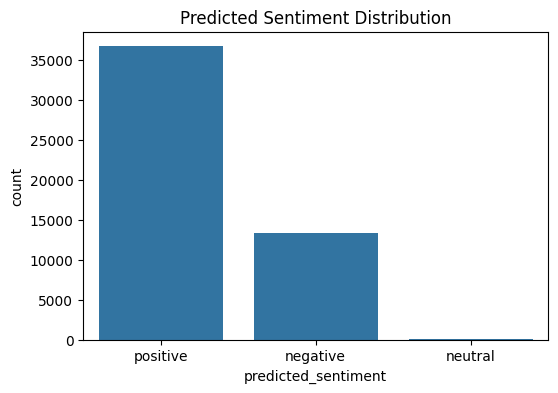

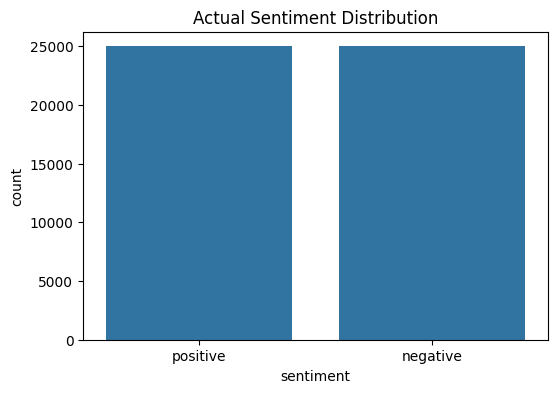

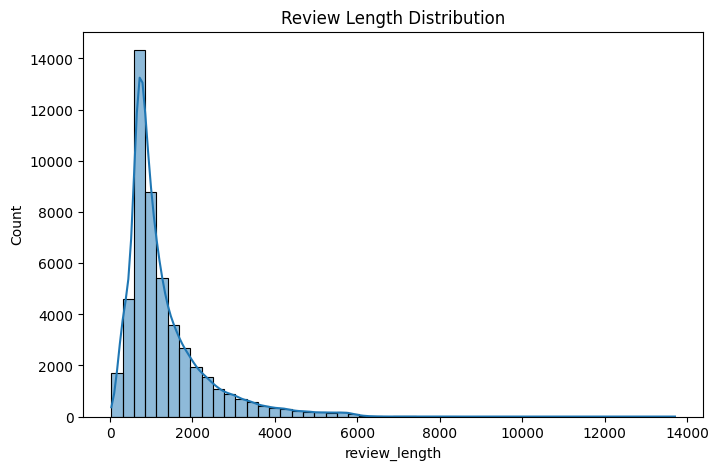

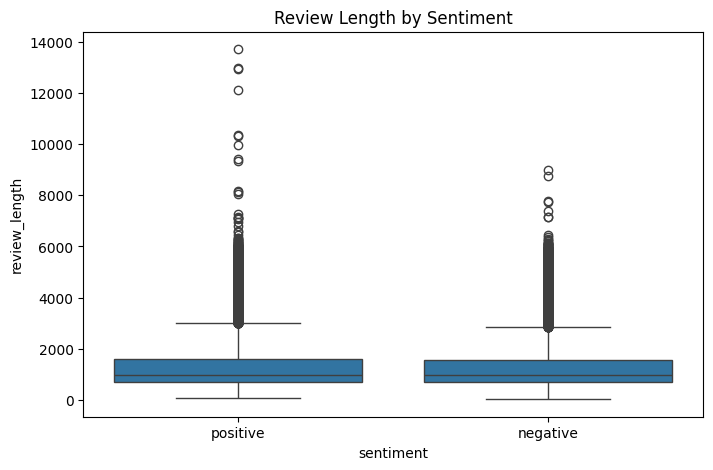

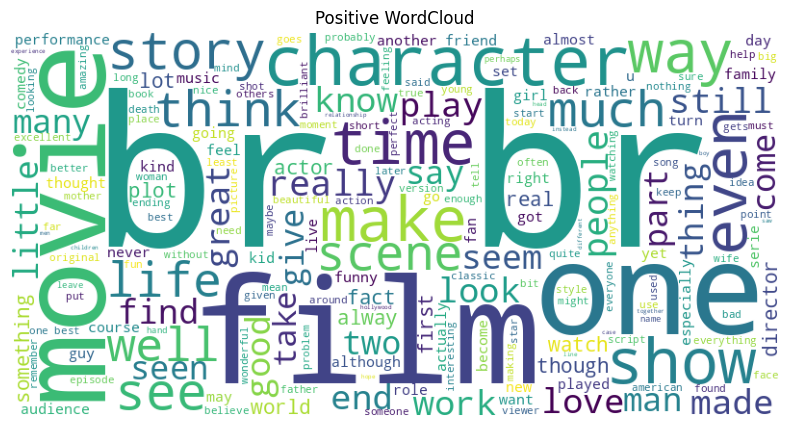

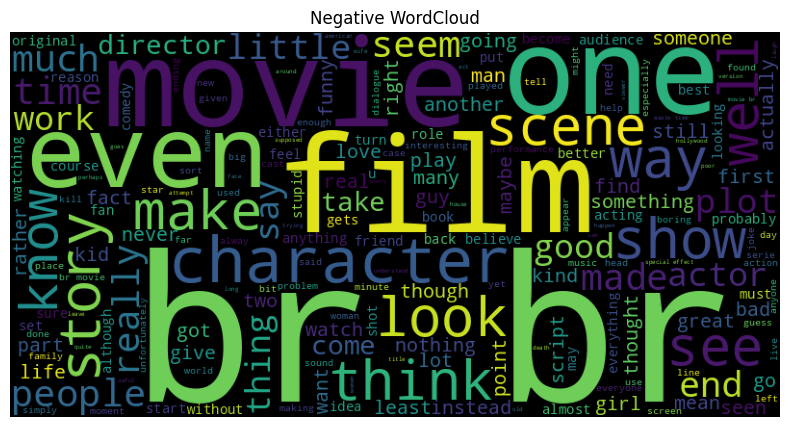

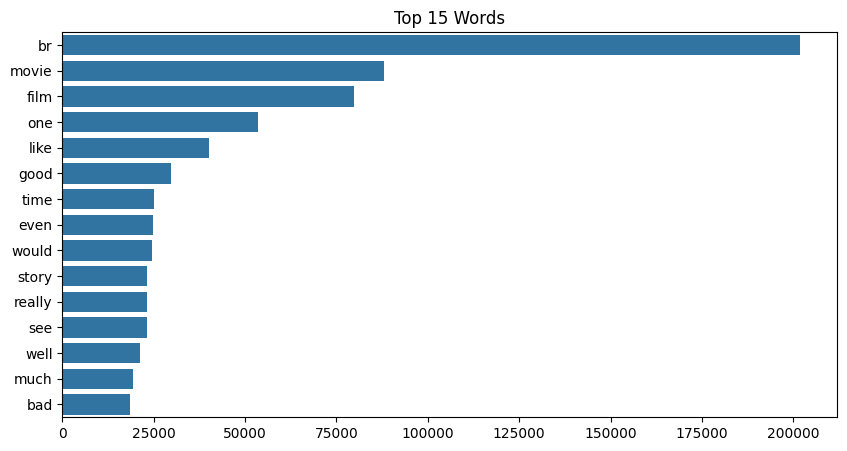

In [ ]:
# =========================
# 📌 1. INSTALL LIBRARIES
# =========================
!pip install textblob wordcloud nltk seaborn scikit-learn

# =========================
# 📌 2. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from textblob import TextBlob
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# 📌 3. UPLOAD DATASET
# =========================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# =========================
# 📌 4. CHECK DATA
# =========================
print(df.head())
print(df.columns)

# =========================
# 📌 5. CLEAN DATA
# =========================
df = df[['review', 'sentiment']]
df.dropna(inplace=True)

# normalize sentiment (IMPORTANT FIX)
df['sentiment'] = df['sentiment'].str.lower()

# =========================
# 📌 6. TEXT CLEANING
# =========================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

# =========================
# 📌 7. SENTIMENT PREDICTION
# =========================
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

df['predicted_sentiment'] = df['clean_review'].apply(get_sentiment)

# =========================
# 📊 8. SENTIMENT COUNT
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='predicted_sentiment', data=df)
plt.title("Predicted Sentiment Distribution")
plt.show()

# =========================
# 📊 9. ACTUAL SENTIMENT COUNT
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Actual Sentiment Distribution")
plt.show()

# =========================
# 📊 10. REVIEW LENGTH
# =========================
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.show()

# =========================
# 📊 11. BOX PLOT
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title("Review Length by Sentiment")
plt.show()

# =========================
# ☁️ 12. WORDCLOUD - POSITIVE
# =========================
positive_text = " ".join(df[df['sentiment']=="positive"]['clean_review'])

if len(positive_text) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Positive WordCloud")
    plt.show()

# =========================
# ☁️ 13. WORDCLOUD - NEGATIVE
# =========================
negative_text = " ".join(df[df['sentiment']=="negative"]['clean_review'])

if len(negative_text) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Negative WordCloud")
    plt.show()

# =========================
# 📊 14. TOP WORDS
# =========================
all_words = " ".join(df['clean_review']).split()
word_freq = Counter(all_words).most_common(15)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Top 15 Words")
plt.show()

# =========================
# 📊 15. BIGRAMS
# =========================
vectorizer = CountVectorizer(ngram_range=(2,2), max_features=15)
X = vectorizer.fit_transform(df['clean_review'])

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_words = [w[0] for w in words_freq]
bigram_counts = [w[1] for w in words_freq]

plt.figure(figsize=(10,5))
sns.barplot(x=bigram_counts, y=bigram_words)
plt.title("Top Bi-Grams")
plt.show()

# =========================
# 📌 DONE
# =========================
print("✔ ALL VISUALIZATIONS COMPLETED")